# Аналитическая механика. Приложение к лекции

## 1. Теоретическая справка

### 1.1. Определения

#### 1.1.1. Криволинейные координаты

Набор из независимых переменных

$$\mathbf{q} \;=
 \begin{pmatrix}
  q_1 \\
  q_2 \\
  q_3
 \end{pmatrix} \;,$$

с помощью которых однозначными формулами

\begin{cases}
  x \;= \varphi_1 \left( q_1, q_2, q_3 \right)\\
  y \;= \varphi_2 \left( q_1, q_2, q_3 \right)\\
  z \;= \varphi_3 \left( q_1, q_2, q_3 \right)
\end{cases}

определяется положение точки в пространстве. Предполагается, что преобразования выше обратимы.

#### 1.1.2. Координатные линии

Кривые, вдоль которых изменяется только 1 из координат.

#### 1.1.3. Локальный базис

Базис из единичных векторов $e_1, e_2, e_3$, направленных по касательным к координатным линиям.

#### 1.1.4. Коэффициенты Ламе (формула используется в 3.1)

Множители вида

$$H_k \;= \left|\frac{\partial \mathbf{r}}{\partial q_k}\right| \;= \left(\sum_{i=1}^{3}\left(\frac{\partial \varphi_i}{\partial q_k} \right)^2\right)^{1/2}, \quad k \;= 1,2,3.$$

### 1.2. Скорость и ускорение для ортогональной системы координат $q_1, q_2, q_3$

#### 1.2.1. Компоненты скорости в системе криволинейных координат (формула используется в 3.2)

$$\mathbf{v_k} \;= H_k \dot q_k \mathbf{e_k}, \quad k \;= 1,2,3$$

#### 1.2.2. Скорость (формула используется в 3.3)

$$\mathbf{v} \;= \sum_{k=1}^{3} \mathbf{v_k}, \quad k \;= 1,2,3$$

#### 1.2.3. Проекции ускорения на касательные к координатным линиям (формула используется в 3.3)

$$w_k \;= \frac{1}{H_k} \left[\frac{d}{dt} \frac{\partial}{\partial \dot q_k} \left(\frac{v^2}{2}\right) - \frac{\partial}{\partial q_k} \left(\frac{v^2}{2}\right)\right], \quad k \;= 1,2,3$$

## 2. Постановка задачи

### 2.1. Цилиндрические координаты

#### 2.1.1. Уравнения

\begin{cases}
  x \;= r cos \left( \varphi \right)\\
  y \;= r sin \left( \varphi \right)\\
  z \;= z
\end{cases}

#### 2.1.2. Локальный базис

In [ ]:
from sympy import *
init_printing(use_unicode=True)

x, y, z, r, u, v, t, phi, teta, sigma, tao, i, j, k = symbols(r'x y z r u v t varphi theta sigma tau \mathbf{e_x} \mathbf{e_y} \mathbf{e_z}')
d_x, d_y, d_z, d_r, d_u, d_v = symbols(r'\dot{x} \dot{y} \dot{z} \dot{r} \dot{u} \dot{v}')
d_phi, d_teta, d_sigma, d_tao, dd_r, dd_z, dd_phi = symbols(r'\dot{varphi} \dot{theta} \dot{sigma} \dot{tau} \ddot{r} \ddot{z} \ddot{varphi}')

z = Function(r'z')(t)
r = Function(r'r')(t)
phi = Function(r'varphi')(t)
d_z = Function(r'\dot{z}')(t)
d_r = Function(r'\dot{r}')(t)
d_phi = Function(r'\dot{\varphi}')(t)
dd_z = Function(r'\ddot{z}')(t)
dd_r = Function(r'\ddot{r}')(t)
dd_phi = Function(r'\ddot{\varphi}')(t)

x = r * cos(phi)
y = r * sin(phi)
z = z

x_r = diff(x, r)
y_r = diff(y, r)
z_r = diff(z, r)

x_phi = diff(x, phi)
y_phi = diff(y, phi)
z_phi = diff(z, phi)

x_z = diff(x, z)
y_z = diff(y, z)
z_z = diff(z, z)

In [ ]:
e_r = x_r * i + y_r * j + z_r * k
e_r

\mathbf{e_x}⋅cos(varphi(t)) + \mathbf{e_y}⋅sin(varphi(t))

In [ ]:
e_phi = x_phi * i + y_phi * j + z_phi * k
e_phi

-\mathbf{e_x}⋅r(t)⋅sin(varphi(t)) + \mathbf{e_y}⋅r(t)⋅cos(varphi(t))

In [ ]:
e_z = x_z * i + y_z * j + z_z * k
e_z

\mathbf{e_z}

#### 2.1.3. Визуализация

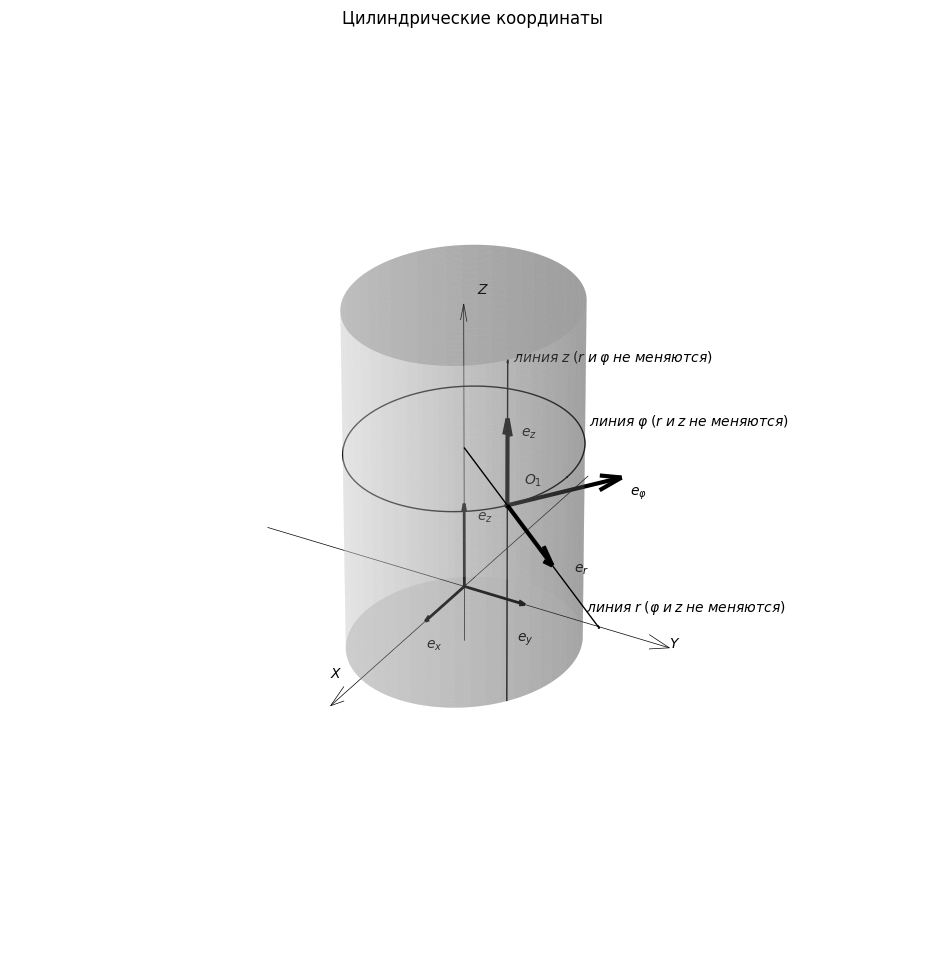

In [ ]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

ax.set_title('Цилиндрические координаты')
ax.grid(False)
ax.set_axis_off()

radius = 5
height = 12
z_bottom = -2
z_top = z_bottom + height

theta = np.linspace(0, 2*np.pi, 100)
z_side = np.linspace(z_bottom, z_top, 50)
Theta, Z_side = np.meshgrid(theta, z_side)
X_side = radius * np.cos(Theta)
Y_side = radius * np.sin(Theta)

r_0 = np.linspace(0, radius, 50)
Theta_base = np.linspace(0, 2*np.pi, 100)
R, Theta_base = np.meshgrid(r_0, Theta_base)
X_bottom = R * np.cos(Theta_base)
Y_bottom = R * np.sin(Theta_base)
Z_bottom_array = z_bottom * np.ones_like(X_bottom)

X_top = R * np.cos(Theta_base)
Y_top = R * np.sin(Theta_base)
Z_top_array = z_top * np.ones_like(X_top)

ax.plot_surface(X_side, Y_side, Z_side, alpha=0.3, color='lightgrey', label='Боковая поверхность')
ax.plot_surface(X_bottom, Y_bottom, Z_bottom_array, alpha=0.2, color='black', label='Нижнее основание')
ax.plot_surface(X_top, Y_top, Z_top_array, alpha=0.2, color='black', label='Верхнее основание')


ax.text(4, -1.75, 5.25, '$O_1$', fontsize=10, color='black')

vector_start_x = [0, 10, 0]
vector_end_x = [0, -10, 0]
ax.quiver(vector_start_x[0], vector_start_x[1], vector_start_x[2],
          vector_end_x[0] - vector_start_x[0],
          vector_end_x[1] - vector_start_x[1],
          vector_end_x[2] - vector_start_x[2],
          color='black', arrow_length_ratio=0.05, linewidth=0.5)
ax.scatter(*vector_start_x, color='black', s=0, marker='o')
ax.scatter(*vector_end_x, color='black', s=0, marker='o')
ax.text(0, -10, 1, '$X$', fontsize=10, color='black')

vector_start_y = [-10, 0, 0]
vector_end_y = [10, 0, 0]
ax.quiver(vector_start_y[0], vector_start_y[1], vector_start_y[2],
          vector_end_y[0] - vector_start_y[0],
          vector_end_y[1] - vector_start_y[1],
          vector_end_y[2] - vector_start_y[2],
          color='black', arrow_length_ratio=0.05, linewidth=0.5)
ax.scatter(*vector_start_y, color='black', s=0, marker='o')
ax.scatter(*vector_end_y, color='black', s=0, marker='o')
ax.text(10, 0, 0, '$Y$', fontsize=10, color='black')

vector_start_z = [0, 0, -2]
vector_end_z = [0, 0, 10]
ax.quiver(vector_start_z[0], vector_start_z[1], vector_start_z[2],
          vector_end_z[0] - vector_start_z[0],
          vector_end_z[1] - vector_start_z[1],
          vector_end_z[2] - vector_start_z[2],
          color='black', arrow_length_ratio=0.05, linewidth=0.5)
ax.scatter(*vector_start_z, color='black', s=0, marker='o')
ax.scatter(*vector_end_z, color='black', s=0, marker='o')
ax.text(0, 1, 10, '$Z$', fontsize=10, color='black')

vector_start_e_x = [0, 0, 0]
vector_end_e_x = [0, -3, 0]
ax.quiver(vector_start_e_x[0], vector_start_e_x[1], vector_start_e_x[2],
          vector_end_e_x[0] - vector_start_e_x[0],
          vector_end_e_x[1] - vector_start_e_x[1],
          vector_end_e_x[2] - vector_start_e_x[2],
          color='black', arrow_length_ratio=0.1, linewidth=2)
ax.scatter(*vector_start_e_x, color='black', s=0, marker='o')
ax.scatter(*vector_end_e_x, color='black', s=0, marker='o')
ax.text(0, -3, -1, '$e_x$', fontsize=10, color='black')

vector_start_e_y = [0, 0, 0]
vector_end_e_y = [3, 0, 0]
ax.quiver(vector_start_e_y[0], vector_start_e_y[1], vector_start_e_y[2],
          vector_end_e_y[0] - vector_start_e_y[0],
          vector_end_e_y[1] - vector_start_e_y[1],
          vector_end_e_y[2] - vector_start_e_y[2],
          color='black', arrow_length_ratio=0.1, linewidth=2)
ax.scatter(*vector_start_e_y, color='black', s=0, marker='o')
ax.scatter(*vector_end_e_y, color='black', s=0, marker='o')
ax.text(2, 1, -2, '$e_y$', fontsize=10, color='black')

vector_start_e_z = [0, 0, 0]
vector_end_e_z = [0, 0, 3]
ax.quiver(vector_start_e_z[0], vector_start_e_z[1], vector_start_e_z[2],
          vector_end_e_z[0] - vector_start_e_z[0],
          vector_end_e_z[1] - vector_start_e_z[1],
          vector_end_e_z[2] - vector_start_e_z[2],
          color='black', arrow_length_ratio=0.1, linewidth=2)
ax.scatter(*vector_start_e_z, color='black', s=0, marker='o')
ax.scatter(*vector_end_e_z, color='black', s=0, marker='o')
ax.text(0, 1, 2, '$e_z$', fontsize=10, color='black')

vector_start_r = [0, 0, 5]
vector_end_r = [12, -9, 5]
ax.quiver(vector_start_r[0], vector_start_r[1], vector_start_r[2],
          vector_end_r[0] - vector_start_r[0],
          vector_end_r[1] - vector_start_r[1],
          vector_end_r[2] - vector_start_r[2],
          color='black', arrow_length_ratio=0.01, linewidth=1)
ax.scatter(*vector_start_r, color='black', s=0, marker='o')
ax.scatter(*vector_end_r, color='black', s=0, marker='o')
ax.text(12, -10, 6, r'$линия \; r \; (\varphi \; и \; z \; не \; меняются)$', fontsize=10, color='black')

vector_start_z = [4, -3, -2]
vector_end_z = [4, -3, 10]
ax.quiver(vector_start_z[0], vector_start_z[1], vector_start_z[2],
          vector_end_z[0] - vector_start_z[0],
          vector_end_z[1] - vector_start_z[1],
          vector_end_z[2] - vector_start_z[2],
          color='black', arrow_length_ratio=0.01, linewidth=1)
ax.scatter(*vector_start_z, color='black', s=0, marker='o')
ax.scatter(*vector_end_z, color='black', s=0, marker='o')
ax.text(3, -1, 9, r'$линия \; z \; (r \; и \; \varphi \; не \; меняются)$', fontsize=10, color='black')

vector_start_e_r = [4, -3, 5]
vector_end_e_r = [8, -6, 5]
ax.quiver(vector_start_e_r[0], vector_start_e_r[1], vector_start_e_r[2],
          vector_end_e_r[0] - vector_start_e_r[0],
          vector_end_e_r[1] - vector_start_e_r[1],
          vector_end_e_r[2] - vector_start_e_r[2],
          color='black', arrow_length_ratio=0.2, linewidth=3)
ax.scatter(*vector_start_e_r, color='black', s=10, marker='o')
ax.scatter(*vector_end_e_r, color='black', s=0, marker='o')
ax.text(9, -6, 5, '$e_r$', fontsize=10, color='black')

vector_start_e_f = [4, -3, 5]
vector_end_e_f = [7, 1, 5]
ax.quiver(vector_start_e_f[0], vector_start_e_f[1], vector_start_e_f[2],
          vector_end_e_f[0] - vector_start_e_f[0],
          vector_end_e_f[1] - vector_start_e_f[1],
          vector_end_e_f[2] - vector_start_e_f[2],
          color='black', arrow_length_ratio=0.2, linewidth=3)
ax.scatter(*vector_start_e_f, color='black', s=10, marker='o')
ax.scatter(*vector_end_e_f, color='black', s=0, marker='o')
ax.text(8, 0, 5, '$e_{\\varphi}$', fontsize=10, color='black')

vector_start_e_z = [4, -3, 5]
vector_end_e_z = [4, -3, 8]
ax.quiver(vector_start_e_z[0], vector_start_e_z[1], vector_start_e_z[2],
          vector_end_e_z[0] - vector_start_e_z[0],
          vector_end_e_z[1] - vector_start_e_z[1],
          vector_end_e_z[2] - vector_start_e_z[2],
          color='black', arrow_length_ratio=0.2, linewidth=3)
ax.scatter(*vector_start_e_z, color='black', s=10, marker='o')
ax.scatter(*vector_end_e_z, color='black', s=0, marker='o')
ax.text(4, -2, 7, '$e_z$', fontsize=10, color='black')

theta = np.linspace(0, 2*np.pi, 100)
x_circle_2 = 5 * np.cos(theta)
y_circle_2 = 5 * np.sin(theta)
z_circle_2 = 5 * np.ones_like(theta)
ax.plot(x_circle_2, y_circle_2, z_circle_2, color='black', linewidth=1)
ax.text(6, 0, 7, r'$линия \; \varphi \; (r \; и \; z \; не \; меняются)$', fontsize=10, color='black')

plt.show()

### 2.2. Найти

- квадрат скорости
- проекции ускорения на касательные к координатным линиям

## 3. Решение задачи

### 3.1. Расчёт коэффициентов Ламе (см. 1.1.4)

#### 3.1.1. расчёт $H_r$

In [ ]:
lame_r_square = (x_r ** 2 + y_r ** 2 + z_r ** 2).simplify()
lame_r = (lame_r_square ** 0.5).simplify()
lame_r

1

#### 3.1.2. расчёт $H_{\varphi}$

In [ ]:
lame_phi_square = (x_phi ** 2 + y_phi ** 2 + z_phi ** 2).simplify()
lame_phi = (lame_phi_square ** 0.5).simplify()

r_1 = symbols(r'r_1', positive=True)
lame_phi_1 = lame_phi.subs(r, r_1).simplify().subs(r_1, r)
lame_phi = lame_phi_1.replace(
    lambda expr: expr.is_Pow and expr.exp == 1.0, lambda expr: expr.base
).simplify()

lame_phi

r(t)

#### 3.1.3. расчёт $H_z$

In [ ]:
lame_z_square = (x_z ** 2 + y_z ** 2 + z_z ** 2).simplify()
lame_z = (lame_z_square ** 0.5).simplify()
lame_z

1

### 3.2. Расчёт компонент скорости (см. 1.2.1)

#### 3.2.1. Расчёт $\mathbf{v_r}$

In [ ]:
v_r = (lame_r * d_r * e_r).simplify()
v_r_square = (lame_r_square * (d_r ** 2)).simplify()
v_r

(\mathbf{e_x}⋅cos(varphi(t)) + \mathbf{e_y}⋅sin(varphi(t)))⋅\dot{r}(t)

#### 3.2.2. Расчёт $\mathbf{v_{\varphi}}$

In [ ]:
v_phi = (lame_phi * d_phi * e_phi).simplify()
v_phi_square = (lame_phi_square * (d_phi ** 2)).simplify()

r_1 = symbols(r'r_1', positive=True)
d_phi_1 = symbols(r'\dot{varphi_1}', positive=True)
v_phi_1 = v_phi.subs(r, r_1).subs(d_phi, d_phi_1).simplify().subs(r_1, r).subs(d_phi_1, d_phi)
v_phi_1 = v_phi_1.replace(
    lambda expr: expr.is_Pow and (expr.exp == 1.0 or expr.exp == 2.0),
    lambda expr: expr.base if expr.exp == 1.0 else expr.base**2
)

v_phi_1

                                                                               ↪
(-\mathbf{e_x}⋅sin(varphi(t)) + \mathbf{e_y}⋅cos(varphi(t)))⋅\dot{\varphi}(t)⋅ ↪

↪  2   
↪ r (t)

#### 3.2.3. Расчёт $\mathbf{v_z}$

In [ ]:
v_z = (lame_z * d_z * e_z).simplify()
v_z_square = (lame_z_square * (d_z ** 2)).simplify()
v_z

\mathbf{e_z}⋅\dot{z}(t)

### 3.3. Расчёт скорости (см. 1.2.2)

In [ ]:
v = (v_r * e_r + v_phi * e_phi + v_z * e_z).simplify()
v_square = (v_r_square + v_phi_square + v_z_square).simplify()
v

            2                                                                  ↪
\mathbf{e_z} ⋅\dot{z}(t) + (\mathbf{e_x}⋅sin(varphi(t)) - \mathbf{e_y}⋅cos(var ↪

↪         2                   3                                                ↪
↪ phi(t))) ⋅\dot{\varphi}(t)⋅r (t) + (\mathbf{e_x}⋅cos(varphi(t)) + \mathbf{e_ ↪

↪                   2           
↪ y}⋅sin(varphi(t))) ⋅\dot{r}(t)

### 3.4. Расчёт проекций ускорения (см. 1.2.3)

#### 3.4.1. Расчёт $w_r$

In [ ]:
v_square_d_r_t = diff(diff(v_square / 2, d_r), t).subs({d_r.diff(t): dd_r})
v_square_r = diff(v_square / 2, r)
w_r = ((lame_r_square ** (-0.5)) * (v_square_d_r_t - v_square_r)).simplify()
w_r

                           2        
\ddot{r}(t) - \dot{\varphi} (t)⋅r(t)

#### 3.4.2. Расчёт $w_{\varphi}$

In [ ]:
v_square_d_phi_t = diff(diff(v_square / 2, d_phi), t).subs({r.diff(t): d_r, d_phi.diff(t): dd_phi})
v_square_phi = diff(v_square / 2, phi)
w_phi = ((lame_phi_square**(-0.5)) * (v_square_d_phi_t - v_square_phi)).simplify()

r_1 = symbols('r_1', positive=True)
w_phi_1 = w_phi.subs(r, r_1).simplify().subs(r_1, r)
w_phi_1 = w_phi_1.replace(
    lambda expr: expr.is_Pow and (expr.exp == 1.0 or expr.exp == 2.0),
    lambda expr: expr.base if expr.exp == 1.0 else expr.base**2
)

w_phi_1

\ddot{\varphi}(t)⋅r(t) + 2⋅\dot{\varphi}(t)⋅\dot{r}(t)

#### 3.4.3. Расчёт $w_z$

In [ ]:
v_square_d_z_t = diff(diff(v_square / 2, d_z), t).subs({d_z.diff(t): dd_z})
v_square_z = diff(v_square / 2, z)
w_z = ((lame_z_square ** (-0.5)) * (v_square_d_z_t - v_square_z)).simplify()
w_z

\ddot{z}(t)